# Dirichlet sonar voxel-cloud figures

Offline notebook (no ROS) that loads a saved `dirichlet_voxels_*.pcd` from
`saved_maps/PCD/` and produces three figures:

1. **Intensity heatmap** — top-down view, colour = `intensity_mean`.
2. **Semantic classification map** — top-down, each cell coloured by its most
   probable class (SEABED / OBJECT / STRUCTURE).
3. **Interactive 3D classified cloud** — Plotly, same class colours, zoom/rotate.

Top-down cells are reduced by the **topmost voxel (max z)** per (x,y) column.
Colours match `dirichlet_paper_plots.py`: SEABED=blue, OBJECT=green, STRUCTURE=red.

In [1]:
# === CONFIG — edit here ======================================================
import os, glob

# Which PCD to load. None -> auto-pick the NEWEST dirichlet_voxels_*.pcd.
# Set to an absolute or relative path to override.
PCD_FILE = None
Lidar_FILE = None      # None -> auto-pick the NEWEST lidar_map*.pcd (seabed-to-sky)

# Voxel size of the saved run [m]. MUST match voxel_mapper r_v for the
# top-down binning to be correct. The example file was saved at 0.05.
VOXEL_RES = 0.05

# Where to write the output figures (next to this notebook).
OUT_DIR = os.path.dirname(os.path.abspath('dirichlet_pcd_figures.ipynb'))

# Semantic classes (match dirichlet_paper_plots.py): FREE=0 excluded from the map.
SEABED, OBJECT, STRUCTURE = 1, 2, 3
CLASS_NAME  = {SEABED: 'SEABED', OBJECT: 'OBJECT', STRUCTURE: 'STRUCTURE'}
CLASS_COLOR = {SEABED: 'tab:blue', OBJECT: 'tab:green', STRUCTURE: 'tab:red'}

# Resolve the saved-maps directory relative to this notebook
# (src/plot_dirichlet -> ../../saved_maps/PCD).
PCD_DIR = os.path.abspath(os.path.join(OUT_DIR, '..', '..', 'saved_maps', 'PCD'))

if PCD_FILE is None:
    cands = sorted(glob.glob(os.path.join(PCD_DIR, 'dirichlet_voxels_*.pcd')))
    if not cands:
        raise FileNotFoundError(f'No dirichlet_voxels_*.pcd in {PCD_DIR}')
    PCD_FILE = max(cands, key=os.path.getmtime)

if Lidar_FILE is None:
    cands = sorted(glob.glob(os.path.join(PCD_DIR, 'lidar_map*.pcd')))
    if not cands:
        raise FileNotFoundError(f'No lidar_map*.pcd in {PCD_DIR}')
    Lidar_FILE = max(cands, key=os.path.getmtime)


print('PCD_DIR  :', PCD_DIR)
print('PCD_FILE :', PCD_FILE)
print('Lidar_FILE:', Lidar_FILE)
print('VOXEL_RES:', VOXEL_RES, 'm')

PCD_DIR  : /home/rosdev/ros2_ws/saved_maps/PCD
PCD_FILE : /home/rosdev/ros2_ws/saved_maps/PCD/dirichlet_voxels_20260615_182308.pcd
Lidar_FILE: /home/rosdev/ros2_ws/saved_maps/PCD/lidar_map_20260615_182310.pcd
VOXEL_RES: 0.05 m


In [2]:
# === PCD LOADER =============================================================
import numpy as np

def load_ascii_pcd(path):
    """Read an ASCII PCD into {field_name: np.float64 array} using the FIELDS
    line. Handles arbitrary field sets (incl. the Dirichlet custom fields that
    open3d cannot return)."""
    with open(path) as f:
        lines = f.readlines()
    fields, data_start = None, None
    for i, ln in enumerate(lines):
        if ln.startswith('FIELDS'):
            fields = ln.split()[1:]
        elif ln.startswith('DATA'):
            if not ln.split()[1].startswith('ascii'):
                raise ValueError(f'{path}: only ASCII PCD supported')
            data_start = i + 1
            break
    if fields is None or data_start is None:
        raise ValueError(f'{path}: not an ASCII PCD with a FIELDS/DATA header')
    rows = [ln.split() for ln in lines[data_start:] if ln.strip()]
    arr = np.array(rows, dtype=np.float64)
    return {name: arr[:, j] for j, name in enumerate(fields)}

vox = load_ascii_pcd(PCD_FILE)
n = len(vox['x'])
sem = np.rint(vox['semantic']).astype(int)

print(f'Loaded {n} voxels from {os.path.basename(PCD_FILE)}')
print('Fields:', list(vox.keys()))
for c in (SEABED, OBJECT, STRUCTURE):
    cnt = int((sem == c).sum())
    print(f'  {CLASS_NAME[c]:10s}: {cnt:6d}  ({100*cnt/n:.1f}%)')

Loaded 9577 voxels from dirichlet_voxels_20260615_182308.pcd
Fields: ['x', 'y', 'z', 'confidence', 'weight', 'semantic', 'pi_free', 'pi_sb', 'pi_obj', 'pi_str', 'intensity_mean']
  SEABED    :   9481  (99.0%)
  OBJECT    :     16  (0.2%)
  STRUCTURE :     80  (0.8%)


In [3]:
# === TOP-DOWN REDUCTION (topmost voxel per column) ==========================
# Bin to columns, keep the highest-z voxel per (ix, iy) column, and return the
# kept voxels as flat arrays so the figures can draw them as big square markers
# (imshow made each 0.05 m cell sub-pixel on a ~25 m map — invisible).

ix = np.floor(vox['x'] / VOXEL_RES).astype(np.int64)
iy = np.floor(vox['y'] / VOXEL_RES).astype(np.int64)

def topmost_columns():
    """Return (cx, cy, idx) for the topmost (max-z) voxel of each occupied
    (ix,iy) column: cx,cy are the voxel-centre coords [m]; idx indexes the
    chosen rows in the loaded arrays."""
    order = np.argsort(vox['z'], kind='stable')        # ascending z
    # Last write per column wins -> highest z. Build a dict col -> row index.
    chosen = {}
    ixo, iyo = ix[order], iy[order]
    for r, (a, b) in enumerate(zip(ixo, iyo)):
        chosen[(int(a), int(b))] = order[r]
    idx = np.fromiter(chosen.values(), dtype=np.int64, count=len(chosen))
    cx = (ix[idx] + 0.5) * VOXEL_RES
    cy = (iy[idx] + 0.5) * VOXEL_RES
    return cx, cy, idx

cx, cy, top_idx = topmost_columns()
print(f'{len(top_idx)} occupied (x,y) columns (topmost voxel each)')

# Marker size so each voxel is a visible square. points^2 area chosen from the
# axis scale; tweak MARKER_PT if voxels look too small/large for your map size.
MARKER_PT = 6.0   # marker side in points


3709 occupied (x,y) columns (topmost voxel each)


wrote /home/rosdev/ros2_ws/src/plot_dirichlet/intensity_map.png


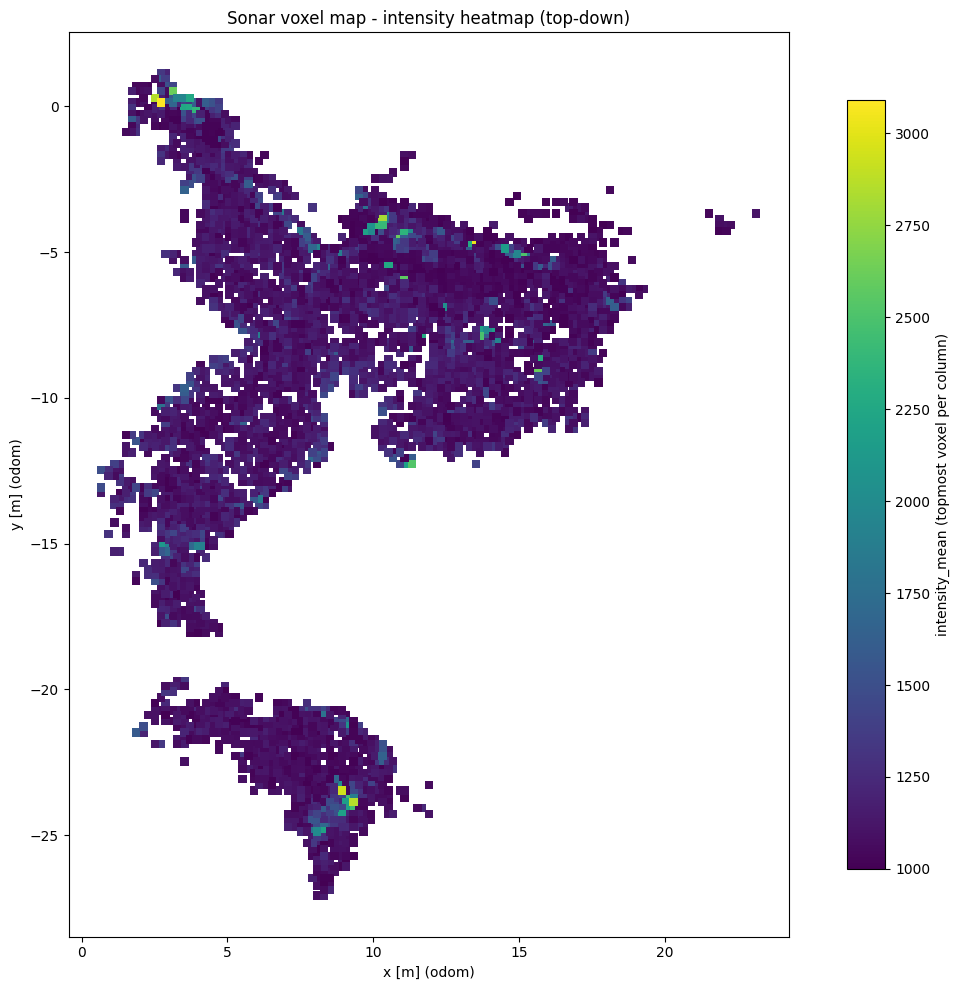

In [4]:
# === FIGURE 1 — INTENSITY HEATMAP (top-down) ================================
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))
sc = ax.scatter(cx, cy, c=vox['intensity_mean'][top_idx],
                s=MARKER_PT**2, marker='s', cmap='viridis',
                edgecolors='none')
cbar = fig.colorbar(sc, ax=ax, shrink=0.85)
cbar.set_label('intensity_mean (topmost voxel per column)')
ax.set_aspect('equal')
ax.set_xlabel('x [m] (odom)')
ax.set_ylabel('y [m] (odom)')
ax.set_title('Sonar voxel map - intensity heatmap (top-down)')
fig.tight_layout()
out = os.path.join(OUT_DIR, 'intensity_map.png')
fig.savefig(out, dpi=200)
print('wrote', out)
plt.show()


wrote /home/rosdev/ros2_ws/src/plot_dirichlet/semantic_map.png


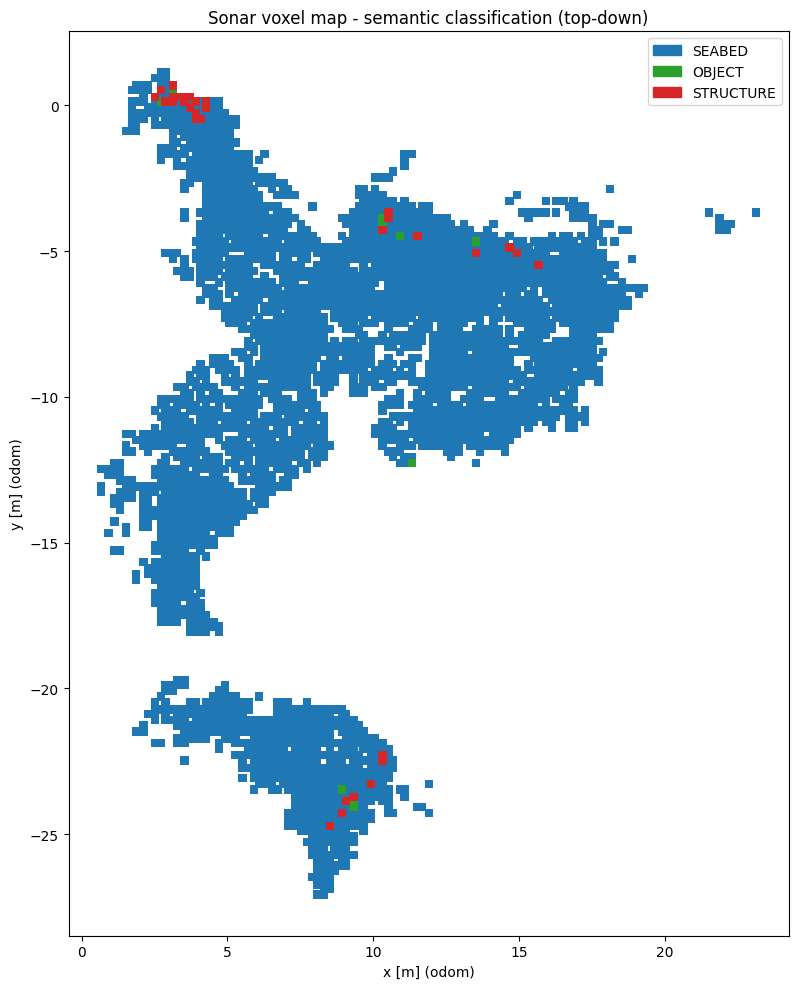

In [5]:
# === FIGURE 2 — SEMANTIC CLASSIFICATION MAP (top-down) ======================
from matplotlib.patches import Patch

sem_top = sem[top_idx]
fig, ax = plt.subplots(figsize=(12, 10))
for c in (SEABED, OBJECT, STRUCTURE):
    m = sem_top == c
    if np.any(m):
        ax.scatter(cx[m], cy[m], s=MARKER_PT**2, marker='s',
                   color=CLASS_COLOR[c], edgecolors='none', label=CLASS_NAME[c])
ax.set_aspect('equal')
ax.set_xlabel('x [m] (odom)')
ax.set_ylabel('y [m] (odom)')
ax.set_title('Sonar voxel map - semantic classification (top-down)')
ax.legend(handles=[Patch(color=CLASS_COLOR[c], label=CLASS_NAME[c])
                   for c in (SEABED, OBJECT, STRUCTURE)], loc='upper right')
fig.tight_layout()
out = os.path.join(OUT_DIR, 'semantic_map.png')
fig.savefig(out, dpi=200)
print('wrote', out)
plt.show()


In [6]:
# === FIGURE 3 — INTERACTIVE 3D CLASSIFIED CLOUD (Plotly) ====================
import plotly.graph_objects as go
import plotly.io as pio

# Plotly needs CSS hex/named colours, not matplotlib 'tab:*' tokens.
import matplotlib.colors as mcolors
HEX = {c: mcolors.to_hex(CLASS_COLOR[c]) for c in (SEABED, OBJECT, STRUCTURE)}

fig3 = go.Figure()
for c in (SEABED, OBJECT, STRUCTURE):
    m = sem == c
    if not np.any(m):
        continue
    fig3.add_trace(go.Scatter3d(
        x=vox['x'][m], y=vox['y'][m], z=vox['z'][m],
        mode='markers', name=CLASS_NAME[c],
        marker=dict(size=2.5, color=HEX[c], symbol='square', opacity=0.85),
    ))

fig3.update_layout(
    title='Sonar voxel map — semantic classification (interactive 3D)',
    scene=dict(
        xaxis_title='x [m]', yaxis_title='y [m]', zaxis_title='z [m]',
        aspectmode='data',   # true physical proportions
    ),
    legend_title_text='class',
    width=1000, height=750,
)

# Save a standalone HTML so it can be opened/shared outside the notebook.
html_out = os.path.join(OUT_DIR, 'semantic_3d.html')
pio.write_html(fig3, html_out, include_plotlyjs='cdn')
print('wrote', html_out)

fig3.show()

wrote /home/rosdev/ros2_ws/src/plot_dirichlet/semantic_3d.html


## Seabed-to-sky cloud (sonar STRUCTURE + LiDAR)

Writes the LiDAR map and the sonar STRUCTURE voxels (semantic == 3) as **two
separate ASCII PCD files** so the MATLAB viewer (x,y,z + single colour + radial
distance) can load each with its own colour:

- `lidar_only.pcd`   — the LiDAR map
- `sonar_struct.pcd` — the sonar STRUCTURE voxels

Each file has fields `x y z range`, where `range = sqrt(x²+y²+z²)` (radial
distance from origin) for distance-based colouring. The LiDAR PCD is
`binary_compressed`, parsed directly here (open3d only returns its xyz).

A combined interactive 3D preview (LiDAR gray + sonar structure red) is also
saved to `seabed_to_sky_3d.html`.

In [7]:
# === SEABED-TO-SKY: sonar STRUCTURE + LiDAR -> two PCD files ================
# Written as TWO clouds so the MATLAB viewer (x,y,z + single colour + radial
# distance) can load each with its own single colour:
#   lidar_only.pcd    — the LiDAR map
#   sonar_struct.pcd  — the sonar STRUCTURE voxels
# Each PCD has fields `x y z range`, where range = sqrt(x^2+y^2+z^2) (radial
# distance from origin) for distance-based colouring.
import struct

# Uses Lidar_FILE chosen in the CONFIG cell (newest lidar_map*.pcd by default).
print('LiDAR file:', Lidar_FILE)


def _lzf_decompress(data, expected_len):
    """Pure-python LZF decode (liblzf format, as used by PCL binary_compressed)."""
    out = bytearray()
    i, n = 0, len(data)
    while i < n:
        ctrl = data[i]; i += 1
        if ctrl < 32:                                # literal run
            run = ctrl + 1
            out += data[i:i + run]; i += run
        else:                                        # back-reference
            length = ctrl >> 5
            if length == 7:
                length += data[i]; i += 1
            ref = ((ctrl & 0x1f) << 8) | data[i]; i += 1
            pos = len(out) - ref - 1
            length += 2
            for _ in range(length):
                out.append(out[pos]); pos += 1
    return bytes(out)


def load_lidar_pcd_xyz(path):
    """Read x,y,z from a PCD. Handles ascii / binary / binary_compressed."""
    raw = open(path, 'rb').read()
    line_end = raw.index(b'\n', raw.index(b'DATA')) + 1
    header = raw[:line_end].decode('ascii', 'replace')
    body = raw[line_end:]
    hl = {l.split()[0]: l.split()[1:] for l in header.splitlines() if l.split()}
    fields = hl['FIELDS']
    npts = int(hl['POINTS'][0])
    data_kind = hl['DATA'][0]
    fi = {f: j for j, f in enumerate(fields)}

    if data_kind.startswith('ascii'):
        rows = [l.split() for l in body.decode().splitlines() if l.strip()]
        a = np.array(rows, dtype=np.float64)
        return {k: a[:, fi[k]] for k in ('x', 'y', 'z')}

    if data_kind.startswith('binary_compressed'):
        comp, uncomp = struct.unpack('<II', body[:8])
        buf = _lzf_decompress(body[8:8 + comp], uncomp)
        arr = np.frombuffer(buf, dtype=np.float32)          # column-major
        cols = {f: arr[j * npts:(j + 1) * npts] for j, f in enumerate(fields)}
        return {k: cols[k].astype(np.float64) for k in ('x', 'y', 'z')}

    # plain binary: interleaved records of summed field sizes
    sizes = [int(s) for s in hl['SIZE']]
    rec = sum(sizes)
    a = np.frombuffer(body[:npts * rec], dtype=np.uint8).reshape(npts, rec)
    off = {f: sum(sizes[:fi[f]]) for f in fields}
    return {k: a[:, off[k]:off[k] + 4].copy().view(np.float32).ravel().astype(np.float64)
            for k in ('x', 'y', 'z')}


def save_ascii_pcd_xyzr(path, x, y, z):
    """Write an ASCII PCD with fields x y z range, range = radial distance."""
    rng = np.sqrt(x * x + y * y + z * z)
    n = len(x)
    cols = np.column_stack([x, y, z, rng]).astype(np.float64)
    with open(path, 'w') as f:
        f.write('# .PCD v.7 - Point Cloud Data file format\n')
        f.write('VERSION .7\n')
        f.write('FIELDS x y z range\n')
        f.write('SIZE 4 4 4 4\n')
        f.write('TYPE F F F F\n')
        f.write('COUNT 1 1 1 1\n')
        f.write(f'WIDTH {n}\n')
        f.write('HEIGHT 1\n')
        f.write('VIEWPOINT 0 0 0 1 0 0 0\n')
        f.write(f'POINTS {n}\n')
        f.write('DATA ascii\n')
        for r in cols:
            f.write(f'{r[0]:.6f} {r[1]:.6f} {r[2]:.6f} {r[3]:.6f}\n')


# --- LiDAR map cloud ---------------------------------------------------------
lidar = load_lidar_pcd_xyz(Lidar_FILE)
lidar_out = os.path.join(OUT_DIR, 'lidar_only.pcd')
save_ascii_pcd_xyzr(lidar_out, lidar['x'], lidar['y'], lidar['z'])
print(f'wrote {lidar_out}  ({len(lidar["x"])} LiDAR points)')

# --- sonar STRUCTURE cloud (semantic == 3) -----------------------------------
m_str = sem == STRUCTURE
n_str = int(m_str.sum())
sonar_out = os.path.join(OUT_DIR, 'sonar_struct.pcd')
save_ascii_pcd_xyzr(sonar_out, vox['x'][m_str], vox['y'][m_str], vox['z'][m_str])
print(f'wrote {sonar_out}  ({n_str} sonar STRUCTURE voxels)')

# --- quick interactive 3D preview (LiDAR gray + sonar structure red) ---------
import plotly.graph_objects as go
fig_sts = go.Figure()
fig_sts.add_trace(go.Scatter3d(
    x=lidar['x'], y=lidar['y'], z=lidar['z'], mode='markers',
    name='LiDAR map', marker=dict(size=1.5, color='gray', opacity=0.5)))
fig_sts.add_trace(go.Scatter3d(
    x=vox['x'][m_str], y=vox['y'][m_str], z=vox['z'][m_str], mode='markers',
    name='sonar STRUCTURE',
    marker=dict(size=3.5, color='red', symbol='square', opacity=0.9)))
fig_sts.update_layout(
    title='Seabed-to-sky: LiDAR map + sonar STRUCTURE',
    scene=dict(xaxis_title='x [m]', yaxis_title='y [m]', zaxis_title='z [m]',
               aspectmode='data'),
    width=1000, height=750)
pio.write_html(fig_sts, os.path.join(OUT_DIR, 'seabed_to_sky_3d.html'),
               include_plotlyjs='cdn')
print('wrote', os.path.join(OUT_DIR, 'seabed_to_sky_3d.html'))
fig_sts.show()

LiDAR file: /home/rosdev/ros2_ws/saved_maps/PCD/lidar_map_20260615_182310.pcd


wrote /home/rosdev/ros2_ws/src/plot_dirichlet/lidar_only.pcd  (84647 LiDAR points)
wrote /home/rosdev/ros2_ws/src/plot_dirichlet/sonar_struct.pcd  (80 sonar STRUCTURE voxels)
wrote /home/rosdev/ros2_ws/src/plot_dirichlet/seabed_to_sky_3d.html
